# Sieć neuronowa do predykcji cen mieszkań

Projekt przedstawia prosty model regresyjny przewidujący ceny mieszkań na podstawie cech nieruchomości. Notebook jest przygotowany do lokalnego uruchamiania w Visual Studio Code.

## Autorzy projektu
- **Mateusz Furgała**
- **Radosław kuc**

Podział pracy wykonanej przez autorów znajduje się na końcu pliku.




## 1. Cel projektu i dane

Celem projektu jest zbudowanie prostej sieci neuronowej do predykcji cen mieszkań na podstawie podstawowych cech nieruchomości. Model korzysta z informacji opisujących lokal, takich jak metraż, liczba pokoi, piętro, rok budowy oraz dane lokalizacyjne.

- Zbiór danych: `data/Houses.csv`
- Źródło danych: Kaggle, House Prices in Poland
- Link do zbioru danych: https://www.kaggle.com/datasets/dawidcegielski/house-prices-in-poland/data
- Typ zadania: regresja


In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
tf.keras.utils.set_random_seed(42)


In [12]:
data_path = Path("data/Houses.csv")
data = pd.read_csv(data_path, encoding="cp1250")

print(f"Liczba rekordów przed czyszczeniem: {len(data)}")
data.head()


Liczba rekordów przed czyszczeniem: 23764


,Unnamed: 0,address,city,floor,id,latitude,longitude,price,rooms,sq,year
0,0,Podgórze Zabłocie Stanisława Klimeckiego,Kraków,2.0,23918.0,50.049224,19.970379,749000.0,3.0,74.05,2021.0
1,1,Praga-Południe Grochowska,Warszawa,3.0,17828.0,52.249775,21.106886,240548.0,1.0,24.38,2021.0
2,2,Krowodrza Czarnowiejska,Kraków,2.0,22784.0,50.066964,19.920025,427000.0,2.0,37.00,1970.0
3,3,Grunwald,Poznań,2.0,4315.0,52.404212,16.882542,1290000.0,5.0,166.00,1935.0
4,4,Ochota Gotowy budynek. Stan deweloperski. Osta...,Warszawa,1.0,11770.0,52.212225,20.972630,996000.0,5.0,105.00,2020.0


### Po uruchomieniu komórki

Po wczytaniu danych wyświetla się informacja o liczbie rekordów oraz podgląd pierwszych wierszy tabeli. W aktualnym wykonaniu zbiór zawiera `23764` rekordy. Na tym etapie widać jeszcze surową postać danych, przed czyszczeniem i przygotowaniem cech do modelu.


## 2. Podstawowe przygotowanie danych

Zostawiamy tylko kroki potrzebne do zbudowania modelu:
- poprawa nazw miast,
- usunięcie zbędnych kolumn tekstowych,
- konwersja danych numerycznych,
- proste odfiltrowanie wartości odstających,
- kodowanie zmiennej `city`.


In [13]:
data = data.rename(columns={"adress": "address"}).copy()
data["city"] = data["city"].replace({"Kraków": "Krakow", "Poznań": "Poznan"})
data = data[data["city"].isin(["Krakow", "Poznan", "Warszawa"])].copy()

data = data.drop(columns=["Unnamed: 0", "address", "id"], errors="ignore")

numeric_columns = ["floor", "latitude", "longitude", "price", "rooms", "sq", "year"]
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="coerce")

data = data.dropna(subset=numeric_columns + ["city"]).copy()
data = data[data["year"].between(1900, 2024)].copy()

data[["floor", "rooms", "year"]] = data[["floor", "rooms", "year"]].round().astype(int)
data = pd.get_dummies(data, columns=["city"], dtype=int)

print(f"Liczba rekordów po czyszczeniu: {len(data)}")
data.head()


Liczba rekordów po czyszczeniu: 23619


,floor,latitude,longitude,price,rooms,sq,year,city_Krakow,city_Poznan,city_Warszawa
0,2,50.049224,19.970379,749000.0,3,74.05,2021,1,0,0
1,3,52.249775,21.106886,240548.0,1,24.38,2021,0,0,1
2,2,50.066964,19.920025,427000.0,2,37.00,1970,1,0,0
3,2,52.404212,16.882542,1290000.0,5,166.00,1935,0,1,0
4,1,52.212225,20.972630,996000.0,5,105.00,2020,0,0,1


### Po czyszczeniu danych

Po wykonaniu tej komórki tabela jest bardziej uporządkowana: zbędne kolumny zostają usunięte, wartości są przygotowane do dalszego przetwarzania, a kolumny związane z miastem mają już postać numeryczną. W aktualnym wykonaniu po czyszczeniu pozostaje `23619` rekordów. Mniejsza liczba obserwacji wynika z odrzucenia części danych podczas czyszczenia.


## 3. Cechy wejściowe i zmienna docelowa

Do modelu wykorzystano dziewięć cech wejściowych opisujących zarówno samo mieszkanie, jak i jego położenie. Taki zestaw pozwala połączyć informacje o standardzie lokalu z informacjami o lokalizacji, które mają duży wpływ na cenę nieruchomości.
- `floor`
- `latitude`
- `longitude`
- `rooms`
- `sq`
- `year`
- `city_Krakow`
- `city_Poznan`
- `city_Warszawa`

Zmienną docelową jest `price`, czyli cena mieszkania. Oznacza to, że projekt dotyczy zadania regresji, ponieważ model nie przypisuje mieszkania do kategorii, lecz przewiduje konkretną wartość liczbową.


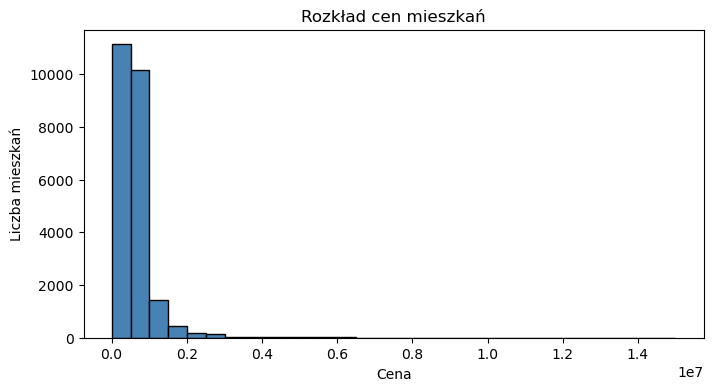

Rozmiar zbioru treningowego: (17156, 9)
Rozmiar zbioru testowego: (5790, 9)


In [14]:
plt.figure(figsize=(8, 4))
plt.hist(data["price"], bins=30, color="steelblue", edgecolor="black")
plt.title("Rozkład cen mieszkań")
plt.xlabel("Cena")
plt.ylabel("Liczba mieszkań")
plt.show()

feature_columns = [
    "floor",
    "latitude",
    "longitude",
    "rooms",
    "sq",
    "year",
    "city_Krakow",
    "city_Poznan",
    "city_Warszawa",
]

X = data[feature_columns]
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

sq_low = X_train["sq"].quantile(0.01)
sq_high = X_train["sq"].quantile(0.99)
price_low = y_train.quantile(0.01)
price_high = y_train.quantile(0.99)

train_mask = X_train["sq"].between(sq_low, sq_high) & y_train.between(price_low, price_high)
test_mask = X_test["sq"].between(sq_low, sq_high)

X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()
X_test = X_test.loc[test_mask].copy()
y_test = y_test.loc[test_mask].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)


### Interpretacja

Po przygotowaniu cech i podziale danych wyświetlane są rozmiary zbioru treningowego i testowego oraz histogram cen mieszkań. W aktualnym wykonaniu zbiór treningowy ma rozmiar `(17156, 9)`, a testowy `(5790, 9)`. Histogram pokazuje, że rozkład cen nie jest idealnie równomierny i zawiera również droższe nieruchomości, co jest typowe dla danych tego typu.


## 4. Model sieci neuronowej

W projekcie pozostawiono jedną sieć neuronową typu `Sequential`, przeznaczoną do regresji. Wybrano architekturę, która w poprzedniej wersji projektu dawała najlepsze wyniki, a jednocześnie pozostaje na tyle prosta, by dobrze nadawała się do omówienia w pracy i do uruchamiania lokalnie w VS Code:

`Dense(64, relu) -> Dense(64, relu) -> Dense(64, relu) -> Dense(64, relu) -> Dense(1)`

Cztery warstwy ukryte uczą się zależności pomiędzy cechami mieszkania a jego ceną, natomiast ostatni neuron zwraca jedną wartość liczbową będącą przewidywaną ceną. Dzięki temu model może odwzorowywać bardziej złożone zależności niż proste modele liniowe.


In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1),
])

model.compile(optimizer="adam", loss="mse")

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0,
)

print("Ostatnia wartość loss:", round(history.history["loss"][-1], 2))
print("Ostatnia wartość val_loss:", round(history.history["val_loss"][-1], 2))


Ostatnia wartość loss: 29865955328.0
Ostatnia wartość val_loss: 29071185920.0


### Na Co Zwrócić Uwagę

Po zakończeniu treningu wypisywane są końcowe wartości `loss` i `val_loss`. W aktualnym uruchomieniu są to odpowiednio `29865955328.0` oraz `29071185920.0` *(wartości mogą się lekko różnić przy kolejnym uruchomieniu modelu)*. Pozostają one do siebie zbliżone, co sugeruje, że model uczy się stabilnie i nie wykazuje wyraźnych oznak silnego przeuczenia.


Wyniki modelu na zbiorze testowym:
MAE:  116225.92
MSE:  61211075475.32
RMSE: 247408.72
R2:   0.6498


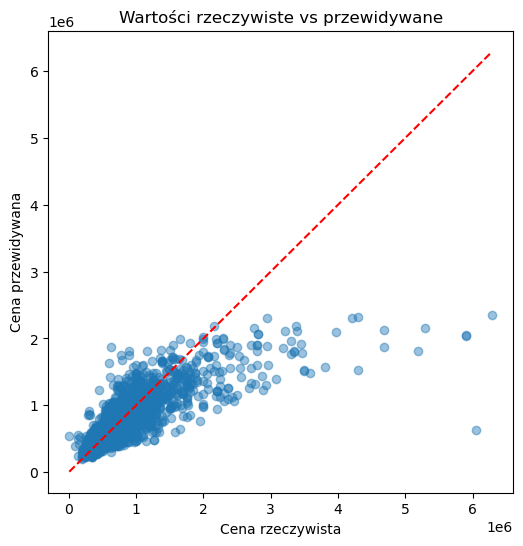

In [16]:
y_pred = model.predict(X_test_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Wyniki modelu na zbiorze testowym:")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.45)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], color="red", linestyle="--")
plt.title("Wartości rzeczywiste vs przewidywane")
plt.xlabel("Cena rzeczywista")
plt.ylabel("Cena przewidywana")
plt.show()


### Interpretacja Wyników

Po wykonaniu tej komórki wyświetlane są podstawowe metryki regresji oraz wykres porównujący wartości rzeczywiste i przewidywane. W aktualnym uruchomieniu model osiągnął `MAE = 116225.92`, `MSE = 61211075475.32`, `RMSE = 247408.72` oraz `R2 = 0.6498` *(wartości mogą się lekko różnić przy kolejnym uruchomieniu modelu)*.

Wykres pokazuje, że wiele punktów znajduje się w pobliżu czerwonej linii odniesienia, choć widoczne są też odchylenia dla części mieszkań. Taki rezultat oznacza, że model wychwytuje istotną część zależności obecnych w danych, ale nadal może popełniać zauważalne błędy dla pojedynczych obserwacji.


## 5. Dodatkowe testy i porównania

Poniższe komórki nie zmieniają głównego celu projektu, lecz pomagają lepiej zinterpretować działanie modelu. Dzięki nim można sprawdzić, czy sieć uczy się stabilnie, jak zachowuje się dla pojedynczej obserwacji oraz czy rzeczywiście daje przewagę nad prostszymi rozwiązaniami.


### 5.1 Wykres przebiegu uczenia

Wykres `loss` i `val_loss` pozwala ocenić przebieg treningu. Jeżeli obie krzywe maleją i pozostają do siebie zbliżone, można uznać, że model uczy się stabilnie i nie wykazuje wyraźnych oznak przeuczenia.


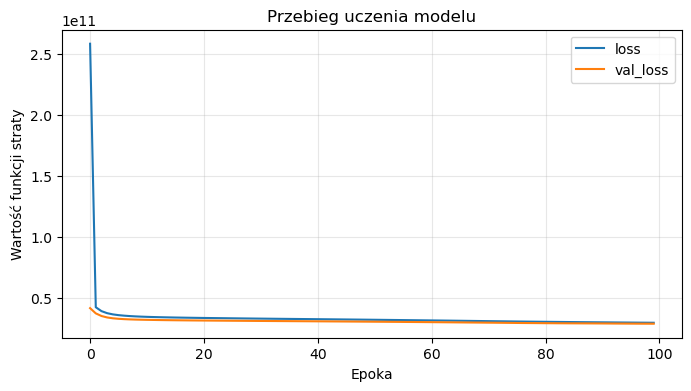

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Przebieg uczenia modelu")
plt.xlabel("Epoka")
plt.ylabel("Wartość funkcji straty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Jak Odczytać Wykres

Na wykresie widoczne są dwie linie: `loss` i `val_loss`. W aktualnym wykonaniu obie krzywe maleją i przez większość epok pozostają stosunkowo blisko siebie *(kształt wykresu może się lekko różnić przy kolejnym uruchomieniu modelu)*. Taki przebieg sugeruje, że model poprawnie dopasowuje się do danych treningowych, a jednocześnie zachowuje rozsądną zdolność uogólniania.


### 5.2 Przykładowa predykcja dla pojedynczego mieszkania

Poniższy test pokazuje wynik modelu dla jednego konkretnego mieszkania ze zbioru testowego. Taki przykład dobrze uzupełnia ogólne metryki, ponieważ pozwala zobaczyć, jak wygląda pojedyncza predykcja i jak duży może być błąd dla konkretnej obserwacji.


In [18]:
sample_index = X_test.index[0]
sample_features = X_test.loc[[sample_index]].copy()
sample_scaled = scaler.transform(sample_features)
sample_prediction = float(model.predict(sample_scaled, verbose=0).flatten()[0])
sample_actual = float(y_test.loc[sample_index])

sample_result = sample_features.copy()
sample_result["cena_rzeczywista"] = sample_actual
sample_result["cena_przewidywana"] = round(sample_prediction, 2)
sample_result["blad_bezwzgledny"] = round(abs(sample_actual - sample_prediction), 2)
sample_result


,floor,latitude,longitude,rooms,sq,year,city_Krakow,city_Poznan,city_Warszawa,cena_rzeczywista,cena_przewidywana,blad_bezwzgledny
4983,6,52.201321,20.962718,2,52.0,2008,0,0,1,640000.0,656151.94,16151.94


### Jak Interpretować Przykład

Tabela pokazuje jedną obserwację ze zbioru testowego wraz z ceną rzeczywistą, ceną przewidywaną przez model oraz błędem bezwzględnym. W aktualnym wykonaniu dla przykładu o indeksie `4983` cena rzeczywista wynosi `640000.0`, cena przewidywana `656151.94`, a błąd bezwzględny `16151.94` *(wartości mogą się lekko różnić przy kolejnym uruchomieniu modelu)*.

To zestawienie pomaga zrozumieć, że o jakości rozwiązania nie należy wnioskować na podstawie jednej obserwacji, lecz na podstawie całego zbioru testowego i obliczonych dla niego metryk.


### 5.3 Model bazowy: LinearRegression

Porównanie z modelem `LinearRegression` pełni rolę punktu odniesienia. Dzięki temu można sprawdzić, czy zastosowanie sieci neuronowej rzeczywiście poprawia jakość predykcji, czy jedynie zwiększa złożoność rozwiązania.


In [19]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_predictions = linear_model.predict(X_test_scaled)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

comparison_df = pd.DataFrame([
    {
        "Model": "Sieć neuronowa",
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
    },
    {
        "Model": "LinearRegression",
        "MAE": round(linear_mae, 2),
        "MSE": round(linear_mse, 2),
        "RMSE": round(linear_rmse, 2),
        "R2": round(linear_r2, 4),
    },
])

comparison_df


,Model,MAE,MSE,RMSE,R2
0,Sieć neuronowa,116225.92,6.121108e+10,247408.72,0.6498
1,LinearRegression,133738.52,7.341872e+10,270958.88,0.5800


### Wniosek Z Porównania

Ta tabela pozwala porównać sieć neuronową z prostszym modelem liniowym. W aktualnym wykonaniu sieć neuronowa osiągnęła `MAE = 116225.92`, `RMSE = 247408.72` i `R2 = 0.6498`, natomiast `LinearRegression` uzyskał `MAE = 133738.52`, `RMSE = 270958.88` i `R2 = 0.5800` *(wartości sieci neuronowej mogą się lekko różnić przy kolejnym uruchomieniu modelu)*.

Przy tej konfiguracji sieć neuronowa zwykle wypada nieco lepiej, co sugeruje, że potrafi uchwycić bardziej złożone zależności niż `LinearRegression`. Jeśli różnice między modelami są nieduże, nadal jest to cenna informacja, bo pokazuje skalę przewagi bardziej rozbudowanego podejścia.


### 5.4 Szybkie eksperymenty porównawcze

Poniższe testy mają charakter pomocniczy. Ich celem jest sprawdzenie, jak na wynik wpływa ograniczenie części informacji wejściowych oraz zmiana proporcji podziału danych. Aby notebook nadal uruchamiał się sprawnie, eksperymenty wykorzystują 40 epok zamiast 100.


In [20]:
def run_neural_experiment(selected_features, test_size=0.25, epochs=40):
    X_exp = data[selected_features]
    y_exp = data["price"]

    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_exp, y_exp, test_size=test_size, random_state=42
    )

    sq_low = X_train_exp["sq"].quantile(0.01)
    sq_high = X_train_exp["sq"].quantile(0.99)
    price_low = y_train_exp.quantile(0.01)
    price_high = y_train_exp.quantile(0.99)

    train_mask = X_train_exp["sq"].between(sq_low, sq_high) & y_train_exp.between(price_low, price_high)
    test_mask = X_test_exp["sq"].between(sq_low, sq_high)

    X_train_exp = X_train_exp.loc[train_mask].copy()
    y_train_exp = y_train_exp.loc[train_mask].copy()
    X_test_exp = X_test_exp.loc[test_mask].copy()
    y_test_exp = y_test_exp.loc[test_mask].copy()

    scaler_exp = StandardScaler()
    X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
    X_test_exp_scaled = scaler_exp.transform(X_test_exp)

    exp_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_exp_scaled.shape[1],)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1),
    ])

    exp_model.compile(optimizer="adam", loss="mse")
    exp_model.fit(
        X_train_exp_scaled,
        y_train_exp,
        validation_split=0.2,
        epochs=epochs,
        batch_size=32,
        verbose=0,
    )

    exp_predictions = exp_model.predict(X_test_exp_scaled, verbose=0).flatten()
    exp_mse = mean_squared_error(y_test_exp, exp_predictions)

    return {
        "Liczba cech": len(selected_features),
        "test_size": test_size,
        "MAE": round(mean_absolute_error(y_test_exp, exp_predictions), 2),
        "RMSE": round(np.sqrt(exp_mse), 2),
        "R2": round(r2_score(y_test_exp, exp_predictions), 4),
    }


quick_experiments = [
    {
        "Eksperyment": "Bez latitude/longitude",
        **run_neural_experiment([
            "floor", "rooms", "sq", "year", "city_Krakow", "city_Poznan", "city_Warszawa"
        ]),
    },
    {
        "Eksperyment": "Bez kolumn city",
        **run_neural_experiment([
            "floor", "latitude", "longitude", "rooms", "sq", "year"
        ]),
    },
    {
        "Eksperyment": "Podział train/test = 80/20",
        **run_neural_experiment(feature_columns, test_size=0.20),
    },
]

quick_experiments_df = pd.DataFrame(quick_experiments)
quick_experiments_df


,Eksperyment,Liczba cech,test_size,MAE,RMSE,R2
0,Bez latitude/longitude,7,0.25,118541.48,250379.33,0.6413
1,Bez kolumn city,6,0.25,121440.08,255587.58,0.6263
2,Podział train/test = 80/20,9,0.20,121983.27,257017.77,0.6377


### Wnioski Z Eksperymentów

W aktualnym wykonaniu eksperyment bez `latitude/longitude` dał `MAE = 118541.48`, `RMSE = 250379.33` i `R2 = 0.6413`, eksperyment bez kolumn `city` dał `MAE = 121440.08`, `RMSE = 255587.58` i `R2 = 0.6263`, a podział `80/20` dał `MAE = 121983.27`, `RMSE = 257017.77` i `R2 = 0.6377` *(wartości mogą się lekko różnić przy kolejnym uruchomieniu modelu)*.

Po usunięciu informacji o lokalizacji lub mieście jakość predykcji lekko spada, co potwierdza znaczenie cech związanych z położeniem mieszkania. Z kolei zmiana proporcji podziału danych na `80/20` daje wynik zbliżony do pozostałych eksperymentów, co można traktować jako sygnał umiarkowanej stabilności modelu.


## 6. Wnioski

Celem projektu było przygotowanie prostej i czytelnej sieci neuronowej do predykcji cen mieszkań na podstawie podstawowych cech nieruchomości. Po uproszczeniu projektu do jednej architektury udało się zachować pełny proces analizy: od wczytania i oczyszczenia danych, przez przygotowanie cech, aż do treningu modelu i oceny jego jakości.

Uzyskane wyniki można uznać za sensowne w kontekście projektu edukacyjnego. W aktualnym wykonaniu model osiągnął `R2 = 0.6498` oraz `MAE = 116225.92` *(wartości mogą się lekko różnić przy kolejnym uruchomieniu modelu)*, co wskazuje, że sieć potrafi uchwycić istotną część zależności między cechami mieszkania a jego ceną, choć nadal popełnia zauważalne błędy dla pojedynczych obserwacji. Jest to naturalne w przypadku uproszczonego modelu trenowanego na ograniczonym zestawie cech.

Dodatkowe testy nadal potwierdzają sens przyjętego podejścia. Porównanie z modelem `LinearRegression` pokazało, że sieć neuronowa osiąga lepsze wyniki od prostego modelu liniowego, a eksperymenty z usuwaniem części cech wykazały, że informacje o lokalizacji i mieście mają realny wpływ na jakość predykcji. Z kolei wyniki po zmianie podziału danych pozostają zbliżone, choć nieco słabsze niż w głównym przebiegu.

Ostatecznie projekt spełnia swój cel: przedstawia prosty, spójny i możliwy do samodzielnego uruchomienia przykład wykorzystania sieci neuronowej w zadaniu regresji. Dzięki temu notebook może pełnić jednocześnie rolę działającego rozwiązania, krótkiej dokumentacji i materiału demonstracyjnego do omówienia tematu predykcji cen mieszkań.


## 7. Podział pracy

Poniższy podział pracy zakłada realizację projektu przez dwie osoby i obejmuje zarówno przygotowanie materiałów, jak i wykonanie części technicznej oraz dokumentacyjnej.

### Radosław Kuc

- wyszukanie tematu projektu i zebranie materiałów wstępnych związanych z predykcją cen mieszkań
- znalezienie odpowiedniego zbioru danych oraz przygotowanie pliku `Houses.csv` do dalszej pracy
- wstępna analiza danych, sprawdzenie kolumn oraz przygotowanie podstawowego czyszczenia danych
- przygotowanie głównej wersji sieci neuronowej, w tym doboru cech wejściowych, skalowania danych i podstawowej konfiguracji modelu
- uporządkowanie struktury projektu i przygotowanie krótkiej dokumentacji startowej, w tym README

### Mateusz Furgała

- współudział w przygotowaniu i testowaniu sieci neuronowej, w tym sprawdzenie jej działania na zbiorze treningowym i testowym
- uruchomienie treningu modelu i obliczenie metryk `MAE`, `MSE`, `RMSE` oraz `R2`
- wykonanie dodatkowych testów porównawczych, takich jak `LinearRegression`, pojedyncza predykcja i szybkie eksperymenty z cechami
- opracowanie interpretacji wyników, komentarzy końcowych oraz sekcji z wnioskami w notebooku
